<a href="https://colab.research.google.com/github/Taynarasales/analise-de-faturamento-/blob/main/analise_de_dados_de_faturamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
from IPython.display import display

In [ ]:
df1 = pd.read_csv('/content/vendas_fevereiro.csv')
df2 = pd.read_csv('/content/vendas_marco.csv')
df3 = pd.read_csv('/content/vendas_janeiro.csv')

In [ ]:
df_juntos = pd.concat([df1, df2, df3], axis=0, ignore_index=True)

In [ ]:
df_juntos = pd.concat([df1, df2, df3],)



In [ ]:
display(df_juntos)


,Data,Produto,Preço,Qtd,Loja
0,2024-02-12,Teclado Digital,3757,8,Belo Horizonte
1,2024-02-25,Baixo 4 Cordas,2636,5,Rio de Janeiro
2,2024-02-22,Teclado Digital,3403,4,São Paulo
3,2024-02-25,Microfone Condensador,4280,8,São Paulo
4,2024-02-5,Baixo 4 Cordas,1344,7,Rio de Janeiro
...,...,...,...,...,...
160,2024-01-17,Guitarra Stratocaster,2619,5,São Paulo
161,2024-01-24,Amplificador 50W,1576,5,São Paulo
162,2024-01-3,Amplificador 50W,2725,8,Rio de Janeiro
163,2024-01-11,Bateria Acústica,4475,3,Rio de Janeiro


In [ ]:
# Criar a coluna de faturamento
df_juntos['Faturamento'] = df_juntos['Preço'] * df_juntos['Qtd']

# Exibir a tabela atualizada
display(df_juntos)


,Data,Produto,Preço,Qtd,Loja,Faturamento
0,2024-02-12,Teclado Digital,3757,8,Belo Horizonte,30056
1,2024-02-25,Baixo 4 Cordas,2636,5,Rio de Janeiro,13180
2,2024-02-22,Teclado Digital,3403,4,São Paulo,13612
3,2024-02-25,Microfone Condensador,4280,8,São Paulo,34240
4,2024-02-5,Baixo 4 Cordas,1344,7,Rio de Janeiro,9408
...,...,...,...,...,...,...
160,2024-01-17,Guitarra Stratocaster,2619,5,São Paulo,13095
161,2024-01-24,Amplificador 50W,1576,5,São Paulo,7880
162,2024-01-3,Amplificador 50W,2725,8,Rio de Janeiro,21800
163,2024-01-11,Bateria Acústica,4475,3,Rio de Janeiro,13425


### Análise Aprofundada do Faturamento Bruto

In [ ]:
# Assegurar que 'Faturamento' esteja calculado e 'Data' no formato correto
# (Esta célula é para garantir que as colunas existam e estejam formatadas corretamente para os gráficos seguintes)
df_juntos['Faturamento'] = df_juntos['Preço'] * df_juntos['Qtd']
df_juntos['Data'] = pd.to_datetime(df_juntos['Data'])

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot') # Adicionar um estilo mais profissional aos gráficos

#### Faturamento Mensal com Linha de Tendência

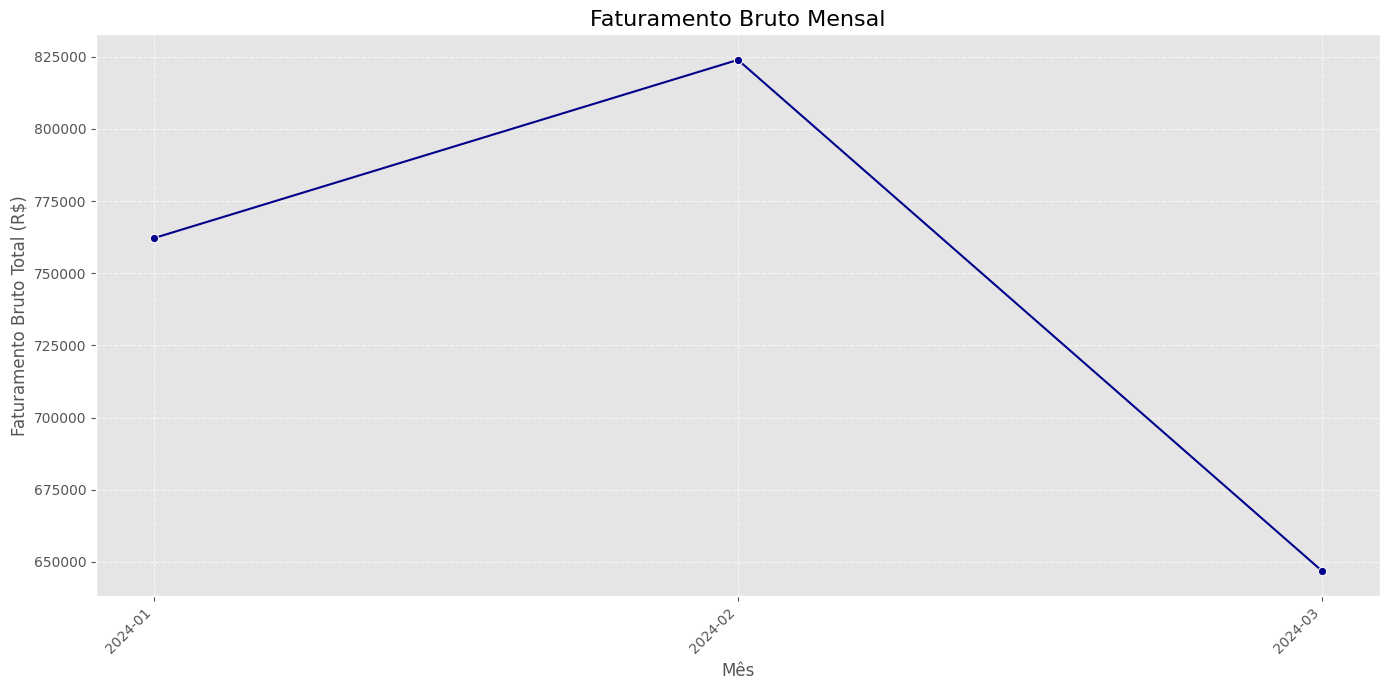

In [ ]:
# Agrupar o faturamento por mês para uma visão de tendência
df_juntos['AnoMes'] = df_juntos['Data'].dt.to_period('M')
faturamento_mensal = df_juntos.groupby('AnoMes')['Faturamento'].sum().reset_index()
faturamento_mensal['AnoMes'] = faturamento_mensal['AnoMes'].astype(str)

plt.figure(figsize=(14, 7))
sns.lineplot(x='AnoMes', y='Faturamento', data=faturamento_mensal, marker='o', color='darkblue')
plt.title('Faturamento Bruto Mensal', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento Bruto Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Top 10 Produtos por Faturamento Bruto

/tmp/ipykernel_26325/2328435818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Faturamento', y='Produto', data=top_produtos, palette='crest_r')


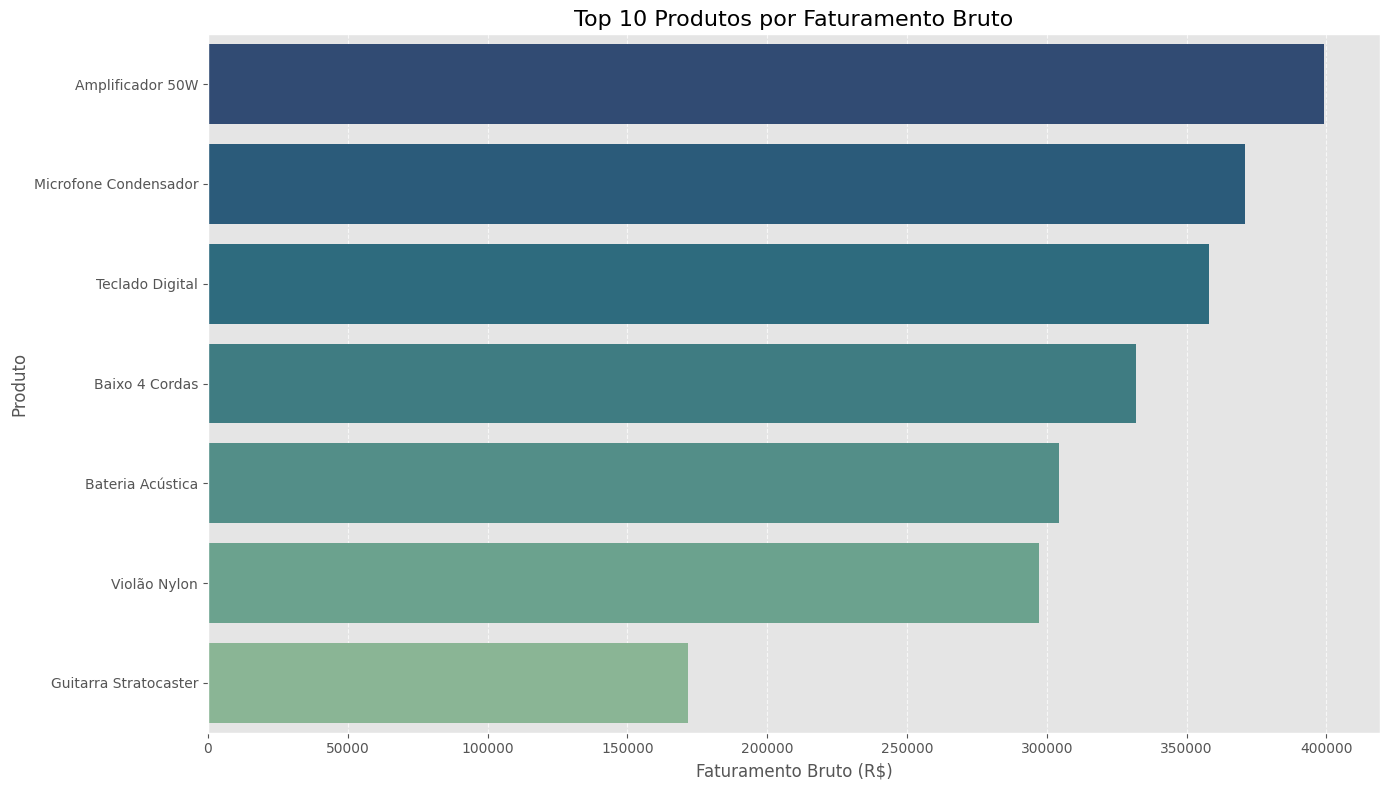

In [ ]:
# Top 10 Produtos
top_produtos = df_juntos.groupby('Produto')['Faturamento'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='Faturamento', y='Produto', data=top_produtos, palette='crest_r', hue='Produto', legend=False)
plt.title('Top 10 Produtos por Faturamento Bruto', fontsize=16)
plt.xlabel('Faturamento Bruto (R$)', fontsize=12)
plt.ylabel('Produto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Top 5 Lojas por Faturamento Bruto

/tmp/ipykernel_26325/3029323946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Faturamento', y='Loja', data=top_lojas, palette='flare_r')


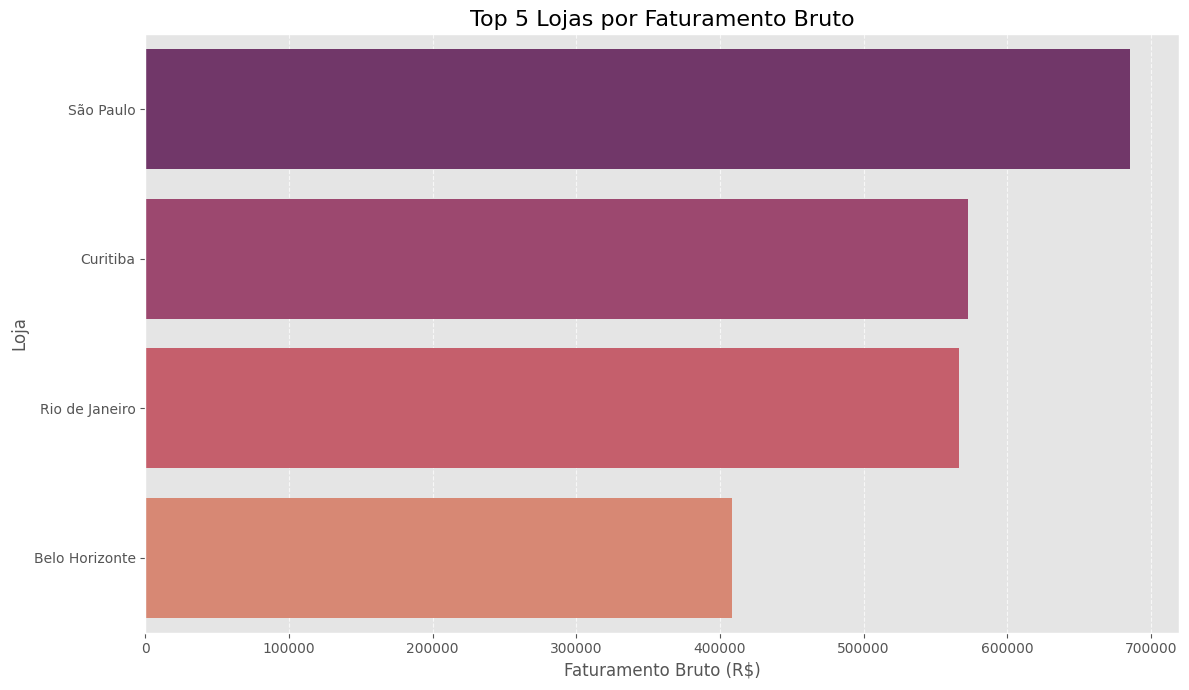

In [ ]:
# Top 5 Lojas
top_lojas = df_juntos.groupby('Loja')['Faturamento'].sum().nlargest(5).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Faturamento', y='Loja', data=top_lojas, palette='flare_r', hue='Loja', legend=False)
plt.title('Top 5 Lojas por Faturamento Bruto', fontsize=16)
plt.xlabel('Faturamento Bruto (R$)', fontsize=12)
plt.ylabel('Loja', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()